# SFT2D example run

A short tour of the model on the pole-to-pole finite-volume mesh: build a grid,
set up the flows, integrate, and check the diagnostics.

The solver is `evolve`, which does Strang splitting internally (advection with
SSPRK(3,3) sub-cycled at its CFL, diffusion with RKL2 super-time-stepping).
There is no hand-written time loop and no boundary condition to apply: the poles
are ordinary finite-volume cells.

In [1]:
# Make `sft2d` importable when running from docs/notebooks/ without
# having pip-installed the package.
import sys, pathlib
try:
    import sft2d
except ModuleNotFoundError:
    sys.path.insert(0, str(pathlib.Path.cwd().parents[1]))

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from sft2d.src.grid import create_grid, total_flux
from sft2d.src.initial_conditions import initialize_field
from sft2d.src.transport_profiles import meridional_flow, differential_rotation
from sft2d.src.stepper import evolve
from sft2d.analysis.analysis import (
    calculate_usflx, calculate_net_flux, calculate_dm,
    calculate_polar_field, calculate_polar_flux,
)
from sft2d.analysis.visualize import plot_bfly, plot_mag

## Grid

`n_theta` counts colatitude cells pole to pole, *including* the two polar caps,
so `create_grid(91, 180)` gives 2-degree cells spanning the full sphere.  The
cell areas sum to $4\pi R^2$ exactly.

In [3]:
grid = create_grid(91, 180)
lat = np.rad2deg(np.pi/2 - grid['colatitude'])
print(f"latitude range: {lat.min():+.1f} .. {lat.max():+.1f} deg")
print(f"cells: {grid['n_theta']} x {grid['n_phi']},  dtheta = {np.rad2deg(grid['dtheta']):.2f} deg")

from sft2d.src.constants import R_SUN_M
print(f"area closure: {float(np.sum(grid['area'])) * grid['n_phi'] / (4*np.pi*R_SUN_M**2):.15f}")

latitude range: -90.0 .. +90.0 deg
cells: 91 x 180,  dtheta = 2.00 deg
area closure: 1.000000000000000


## Flows and initial condition

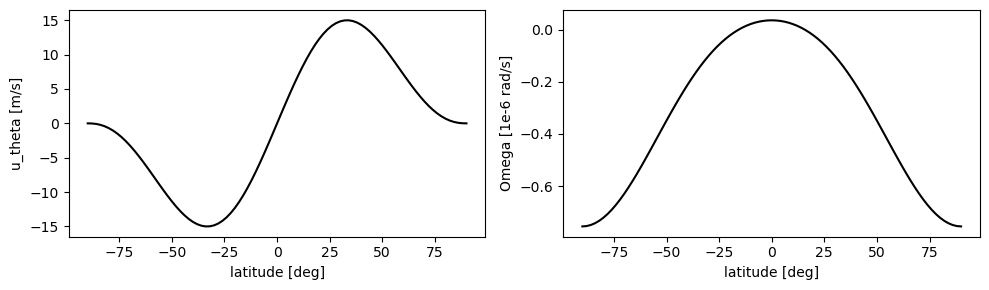

In [5]:
mf = meridional_flow(grid, peak_speed=-15.0)          # u_theta [m/s]
dr = differential_rotation(grid, rotation='solar', frame='carrington')  # Omega [rad/s]
eta = 2.5e8                                          # m^2/s = 250 km^2/s

field0 = initialize_field(grid, 'dipole') * 3.0

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(lat, mf[:, 0], 'k'); ax[0].set_xlabel('latitude [deg]'); ax[0].set_ylabel('u_theta [m/s]')
ax[1].plot(lat, dr[:, 0]*1e6, 'k'); ax[1].set_xlabel('latitude [deg]'); ax[1].set_ylabel('Omega [1e-6 rad/s]')
fig.tight_layout()

## Integrate

`evolve` picks its own stage and sub-cycle counts; `return_stats=True` reports
them.  Compare `rkl2_stages` against `explicit_diffusion_steps_avoided` to see
what super-time-stepping is buying.

In [6]:
bfly, days = [], []

class Recorder:
    def record(self, day, B):
        if day % 5 == 0:
            days.append(day)
            bfly.append(B.mean(axis=1).copy())

B, stats = evolve(field0, grid, mf, dr, eta, num_days=365,
                  recorder=Recorder(), return_stats=True)

for k, v in stats.items():
    print(f"{k:38s} {v:.4g}")

dt                                     8.64e+04
dt_advection_cfl                       9260
dt_diffusion_explicit                  1434
advection_subcycles_per_half_step      5
rkl2_stages                            16
explicit_diffusion_steps_avoided       60.25


## Conservation check\n\nThe transport operators are conservative by construction, so with no source term the signed flux must not move.

In [7]:
f0, f1 = calculate_net_flux(field0, grid), calculate_net_flux(B, grid)
u0 = calculate_usflx(field0, grid)
print(f"net flux      {f0:+.6e} -> {f1:+.6e} Mx")
print(f"drift         {abs(f1-f0)/u0:.3e}  (relative to total unsigned flux)")

net flux      +4.194304e+06 -> +3.103785e+08 Mx
drift         1.511e-14  (relative to total unsigned flux)


## Diagnostics

In [8]:
pn, ps = calculate_polar_field(B, grid, pol_cap_extent_deg=20)   # poleward of +/-70 deg
fn, fs = calculate_polar_flux(B, grid, pol_cap_extent_deg=20)
print(f"polar field   N {pn:+.3f} G      S {ps:+.3f} G")
print(f"polar flux    N {fn:+.4e} Mx  S {fs:+.4e} Mx")
print(f"axial dipole  {calculate_dm(B, grid):+.4f} G")
print(f"unsigned flux {calculate_usflx(B, grid):.4e} Mx")

polar field   N +1.074 G      S -1.074 G
polar flux    N +1.9682e+21 Mx  S -1.9682e+21 Mx
axial dipole  +0.6503 G
unsigned flux 2.0085e+22 Mx


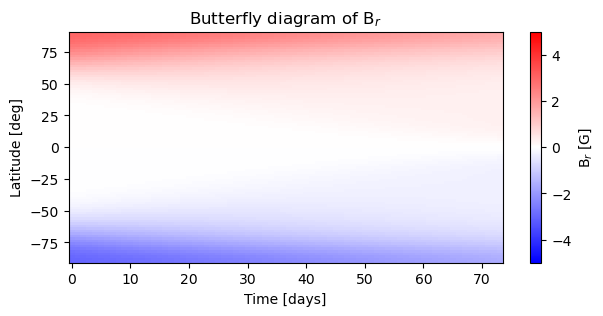

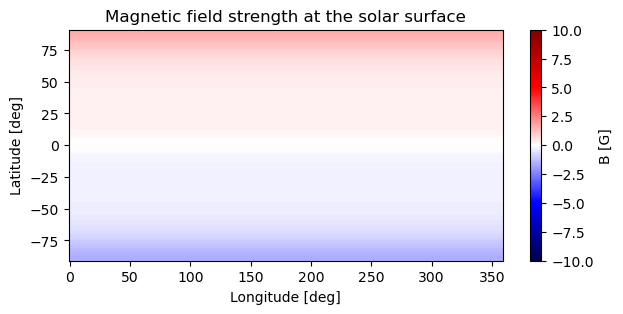

In [9]:
plot_bfly(np.array(bfly), grid, bmax=5)
plot_mag(B, grid, bmax=10)